# Rolling window PCA 

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA

import flexible_pca
import importlib
importlib.reload(flexible_pca)
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

import cell_analysis
importlib.reload(cell_analysis)
from cell_analysis import Cell

from concurrent import futures
from tqdm import tqdm

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib widget

## Definitions

In [40]:
analyzer = MultiSessionPCA({
    # 'epok': [-100, 300],
    # 'bin_size': 1,
    # 'smooth_ker_size': 25,
    # 'alignment_point': 'go_cue',
    # 'ssd_number': 2,
    # 'normalize': False,
    # 'delta': False,
    # 'subtract_average_PSTH': False,
    'excluded_sessions': [],
    'min_cells_per_session': 10,
    'min_trials_per_condition': 20,
    'monkey': 'fiona',
    'n_pca_components': 5,
    'n_workers': 19,
    'normalize': False,
    'required_directions': [0],
    'required_trial_types': ['GO', 'STOP', 'CONT'],
})

analyzer.load_data('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')
analyzer.cell_df = analyzer.cell_df[analyzer.cell_df['cell_type'] == 'msn']

analyzer.validate_all_sessions()
print(f"✓ Valid sessions: {len(analyzer.valid_sessions)}")

cell_df = analyzer.cell_df[analyzer.cell_df['trial_session'].isin(analyzer.valid_sessions)]
cell_df = cell_df[~cell_df['cell_ID'].isin([2134])]
cell_df = cell_df[~cell_df['cell_ID'].isin([1352])]

Loading data from: ../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl
✓ Database loaded: 1,939,269 cell-trial combinations
  Total sessions: 61
  Total unique cells: 3096
✓ Session statistics computed for 50 sessions
  Excluded sessions: 0
  Candidate sessions: 50
Validating sessions...
--------------------------------------------------------------------------------
✓ fi211102a: Valid (70 cells)
✓ fi211110a: Valid (57 cells)
✓ fi211115a: Valid (56 cells)
✓ fi210909a: Valid (52 cells)
✓ fi210907a: Valid (52 cells)
✓ fi211118a: Valid (46 cells)
✓ fi211104a: Valid (45 cells)
✓ fi211025a: Valid (44 cells)
✓ fi210817a: Valid (43 cells)
✓ fi210811a: Valid (43 cells)
✓ fi211111a: Valid (37 cells)
✓ fi210725a: Valid (36 cells)
✓ fi210818a: Valid (34 cells)
✓ fi210728a: Valid (34 cells)
✓ fi210908a: Valid (34 cells)
✓ fi211109a: Valid (32 cells)
✓ fi211108a: Valid (32 cells)
✓ fi210823a: Valid (31 cells)
✓ fi210721a: Valid (31 cells)
✓ fi210727a: Valid (31 cells

In [41]:
# Load data
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl')
# cell_df = pd.read_pickle('../../data/unified_cell_trial_data/alt_saccade_params_msn_fiona_cell_trial_data.pkl')

# Filter data
# excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
# cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
# cell_df = cell_df[cell_df['trial_failed'] == False]

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"Data loaded: {len(cell_df):,} trials, {cell_df['cell_ID'].nunique()} cells")

Data loaded: 723,793 trials, 1281 cells


## PCA analysis

In [53]:
# Create FlexiblePCA instance
SMOOTH_KER_SIZE = 15
CONTRA_DIR = 0
WIN_SIZE = 200
EPOKs_START = -300
EPOKs_END = 200
SKIP_STEP = 50
ALIGNMENT_POINT = 'go_cue'
epok_base = np.arange(EPOKs_START, EPOKs_END + 1, SKIP_STEP)
EPOKS = np.array([[t, t+WIN_SIZE] for t in epok_base])

fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=SMOOTH_KER_SIZE,
    n_components=5,
    pca_function=TruncatedSVD,
    n_jobs=-1,
    z_score=False,
    verbose=False,
)

def fit_model_for_epoch(model, epoch):
    specs = [
        TrialSpec('GO', direction=CONTRA_DIR, epoch=epoch, alignment=ALIGNMENT_POINT, success_only=True, failed_only=False, is_slow_go=None),
        TrialSpec(
            'STOP', direction=CONTRA_DIR, 
            epoch=epoch, alignment=ALIGNMENT_POINT, 
            success_only=True, 
            failed_only=False,
        ),
    ]
    model.fit(specs)
    return model

fitted_models = []
with futures.ProcessPoolExecutor() as executor:
    results = [executor.submit(fit_model_for_epoch, fpca, epoch) for epoch in EPOKS]
for future in tqdm(futures.as_completed(results), total=len(EPOKS), desc="Fitting PCA models for epochs"):
    fitted_models.append(future.result())
    


Fitting PCA models for epochs: 100%|██████████| 11/11 [00:00<00:00, 85.31it/s]


In [49]:
ps1s = np.array([np.abs(m.pca_model.components_[0]) for m in fitted_models])

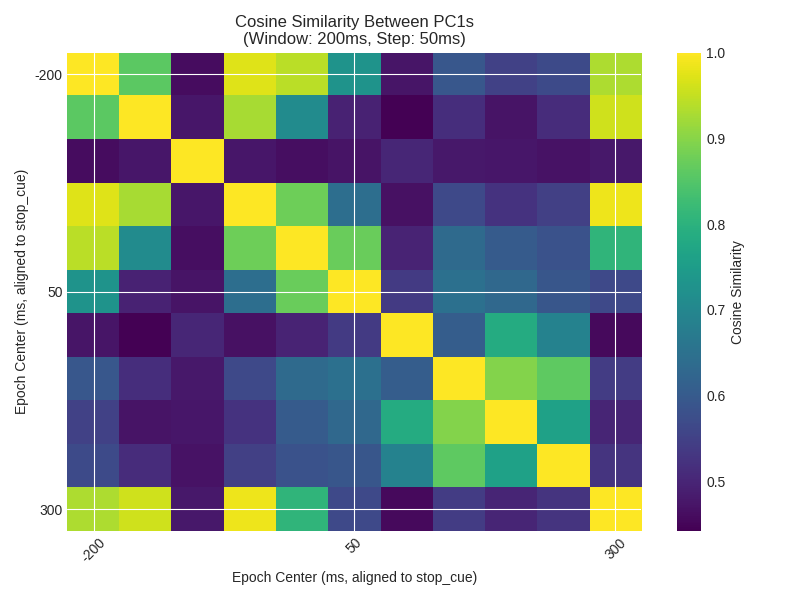

In [52]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import zscore
# Compute cosine distance matrix

# Cosine similarity between all pairs of PC1s
cos_sim = cosine_similarity(ps1s)

# Z-score the cosine similarity matrix
# cos_sim_zscore = zscore(cos_sim)
cos_sim_zscore = cos_sim

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_sim_zscore, cmap='viridis', aspect='auto')

# Set ticks to show epoch centers
tick_indices = np.arange(0, len(EPOKS), 5)
tick_labels = [f"{int((e[0] + e[1])/2)}" for e in EPOKS[tick_indices]]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)
ax.set_yticks(tick_indices)
ax.set_yticklabels(tick_labels)

# Labels
ax.set_xlabel(f'Epoch Center (ms, aligned to {ALIGNMENT_POINT})')
ax.set_ylabel(f'Epoch Center (ms, aligned to {ALIGNMENT_POINT})')
ax.set_title(f'Cosine Similarity Between PC1s\n(Window: {WIN_SIZE}ms, Step: {SKIP_STEP}ms)')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity')

plt.tight_layout()
plt.show()

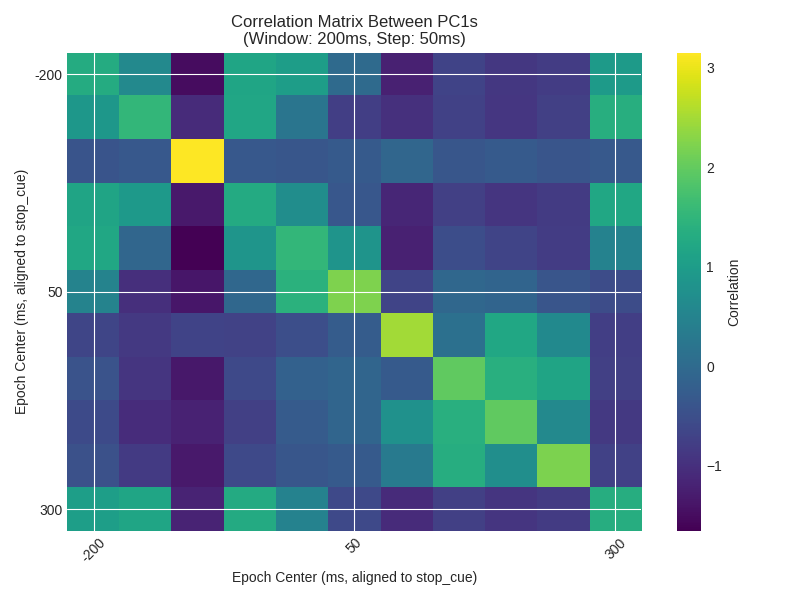

In [51]:
corr_mat = np.corrcoef(ps1s)

corr_mat = zscore(corr_mat, axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_mat, cmap='viridis', aspect='auto')

tick_indices = np.arange(0, len(EPOKS), 5)
tick_labels = [f"{int((e[0] + e[1]) / 2)}" for e in EPOKS[tick_indices]]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)
ax.set_yticks(tick_indices)
ax.set_yticklabels(tick_labels)

ax.set_xlabel(f'Epoch Center (ms, aligned to {ALIGNMENT_POINT})')
ax.set_ylabel(f'Epoch Center (ms, aligned to {ALIGNMENT_POINT})')
ax.set_title(f'Correlation Matrix Between PC1s\n(Window: {WIN_SIZE}ms, Step: {SKIP_STEP}ms)')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()